# 多层防御系统数值模拟

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'WenQuanYi Micro Hei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [3]:
def solve_n_layer(M0, D0, n_layers, tol=1e-8, max_iter=100):
    """
    求解 n 层防御系统的防御势分配
    返回: D_list (长度为 n_layers), M_list (长度为 n_layers+1, M0 为第一个)
    """
    # 二分法搜索 D1
    D1_low, D1_high = 0.0, D0
    
    for _ in range(max_iter):
        D1 = (D1_low + D1_high) / 2
        M_prev = M0
        D_list = []
        M_list = [M0]
        
        # 第1层
        M1 = M_prev * np.exp(-D1 / M_prev) if M_prev > 0 else 0
        D_list.append(D1)
        M_list.append(M1)
        M_prev = M1
        
        # 后续层数
        for layer in range(2, n_layers + 1):
            D_next = M_list[-2] - M_list[-1]  # D_i = M_{i-1} - M_i
            D_list.append(D_next)
            M_next = M_list[-1] * np.exp(-D_next / M_list[-1]) if M_list[-1] > 0 else 0
            M_list.append(M_next)
        
        D0_calc = sum(D_list)
        
        if abs(D0_calc - D0) < tol:
            break
        elif D0_calc < D0:
            D1_low = D1
        else:
            D1_high = D1
    
    return D_list, M_list

In [4]:
plt.rcParams['text.usetex'] = False  # 如果系统没有 LaTeX，保持 False
# 或者使用 matplotlib 内置的 mathtext（默认支持，无需安装 LaTeX）

C:\Users\86187\AppData\Local\Temp\ipykernel_10396\3900381730.py:25: RuntimeWarning: overflow encountered in double_scalars
  M_next = M_list[-1] * np.exp(-D_next / M_list[-1]) if M_list[-1] > 0 else 0


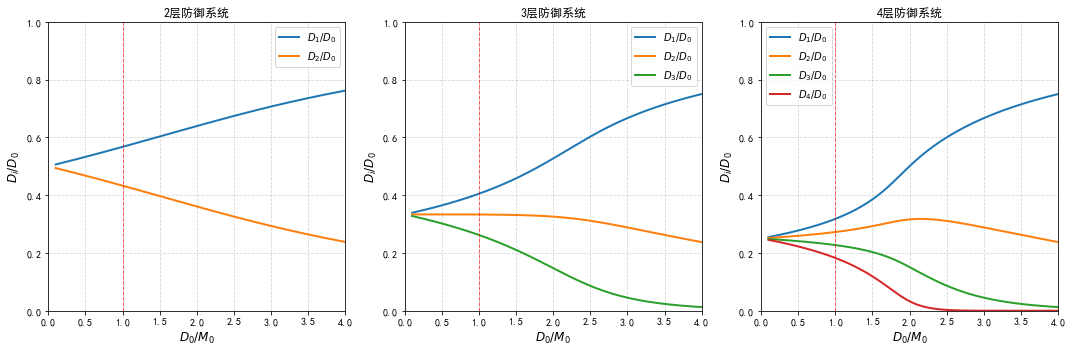

In [5]:
# ========== 图6.5：三个子图 ==========
x_vals = np.linspace(0.1, 4, 150)  # D0/M0 从 0.1 到 4，避开 0 避免除零

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#fig.suptitle('不同层数防御系统中各层防御势占比随 D0/M0 的变化', fontsize=14)

# 存储图6.6的数据
M_ratios_for_fig6 = {2: [], 3: [], 4: []}

for idx, n in enumerate([2, 3, 4]):
    ax = axes[idx]
    D_ratios = {i: [] for i in range(1, n+1)}
    
    for ratio in x_vals:
        D0 = ratio * 1.0  # M0 = 1
        D_list, M_list = solve_n_layer(M0=1.0, D0=D0, n_layers=n)
        
        # 计算各层防御势占比
        for i in range(1, n+1):
            D_ratios[i].append(D_list[i-1] / D0 if D0 > 0 else 0)
        
        # 存储图6.6的数据：最终剩余导弹比例
        M_ratios_for_fig6[n].append(M_list[-1] / 1.0)
    
    # 绘图
    for i in range(1, n+1):
        ax.plot(x_vals, D_ratios[i], label=f'$D_{i}/D_0$', linewidth=2)
    
    ax.set_xlabel('$D_0 / M_0$', fontsize=12)
    ax.set_ylabel('$D_i / D_0$', fontsize=12)
    ax.set_title(f'{n}层防御系统', fontsize=12)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axvline(x=1, color='r', linestyle='--', alpha=0.6, linewidth=1)

plt.tight_layout()
plt.savefig('Figure_6_5.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\86187\AppData\Local\Temp\ipykernel_10396\3900381730.py:25: RuntimeWarning: overflow encountered in double_scalars
  M_next = M_list[-1] * np.exp(-D_next / M_list[-1]) if M_list[-1] > 0 else 0


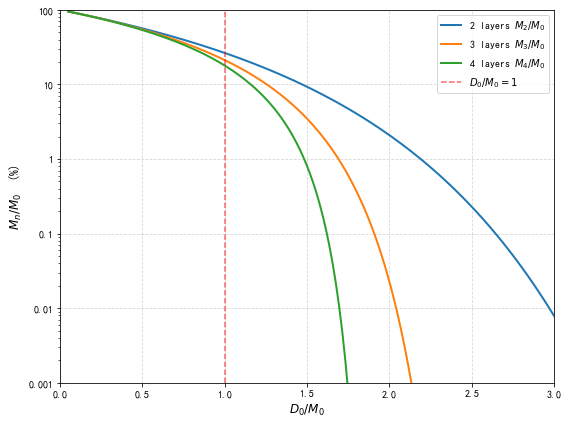

In [7]:
# ========== 图6.6：剩余导弹比例（百分比，对数纵轴）==========
plt.figure(figsize=(8, 6))

# 使用相同的 x_vals，但范围可能调整到 0~3（按要求）
x_vals_fig6 = np.linspace(0.05, 3, 150)

M_ratios_fig6 = {2: [], 3: [], 4: []}

for ratio in x_vals_fig6:
    D0 = ratio * 1.0
    for n in [2, 3, 4]:
        _, M_list = solve_n_layer(M0=1.0, D0=D0, n_layers=n)
        M_ratios_fig6[n].append(M_list[-1] / 1.0 * 100)  # 转换为百分比

# 绘图
plt.plot(x_vals_fig6, M_ratios_fig6[2], label='2 layers $M_2/M_0$', linewidth=2)
plt.plot(x_vals_fig6, M_ratios_fig6[3], label='3 layers $M_3/M_0$', linewidth=2)
plt.plot(x_vals_fig6, M_ratios_fig6[4], label='4 layers $M_4/M_0$', linewidth=2)

plt.xlabel('$D_0 / M_0$', fontsize=12)
plt.ylabel('$M_n / M_0$  (%)', fontsize=12)
#plt.title('不同防御层数下来袭导弹剩余比例', fontsize=14)
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
plt.gca().set_yticklabels(['0.001', '0.01', '0.1', '1', '10', '100'])
plt.ylim(0.001, 100)
plt.xlim(0, 3)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='r', linestyle='--', alpha=0.6, label='$D_0/M_0=1$')
plt.legend()
plt.tight_layout()
plt.savefig('Figure_6_6.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
def solve_n_layer_mirv(M0, D0, alpha=1, tol=1e-8, max_iter=100):
    """4层防御，第3层前分裂为alpha枚"""
    D1_low, D1_high = 0.0, D0
    
    for _ in range(max_iter):
        D1 = (D1_low + D1_high) / 2
        
        # 第1层
        M1 = M0 * np.exp(-D1 / M0) if M0 > 0 else 0
        
        # 第2层
        D2 = M0 - M1
        if D2 < 0: D2 = 0
        M2 = M1 * np.exp(-D2 / M1) if M1 > 0 else 0
        
        # 第3层（分裂后拦截）
        D3_raw = M1 - alpha * M2
        if D3_raw <= 0:
            D3 = 0.0
            M3 = alpha * M2
        else:
            D3 = D3_raw
            M3 = alpha * M2 * np.exp(-D3 / (alpha * M2)) if alpha * M2 > 0 else 0
        
        # 第4层
        D4_raw = alpha * M2 - M3
        if D4_raw <= 0:
            D4 = 0.0
            M4 = M3
        else:
            D4 = D4_raw
            M4 = M3 * np.exp(-D4 / M3) if M3 > 0 else 0
        
        D0_calc = D1 + D2 + D3 + D4
        
        if abs(D0_calc - D0) < tol:
            break
        elif D0_calc < D0:
            D1_low = D1
        else:
            D1_high = D1
    
    return [D1, D2, D3, D4], [M0, M1, M2, M3, M4]

C:\Users\86187\AppData\Local\Temp\ipykernel_10396\740048751.py:32: RuntimeWarning: overflow encountered in double_scalars
  M4 = M3 * np.exp(-D4 / M3) if M3 > 0 else 0


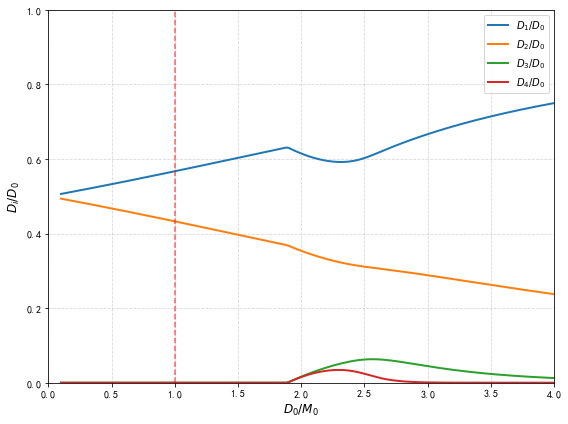

In [9]:
#  4层防御，α=10
x_vals = np.linspace(0.1, 4, 200)  # D0/M0
alpha = 10
D_ratios = {1:[], 2:[], 3:[], 4:[]}

for ratio in x_vals:
    D0 = ratio * 1.0
    D_list, _ = solve_n_layer_mirv(M0=1.0, D0=D0, alpha=alpha)
    for i in range(1,5):
        D_ratios[i].append(D_list[i-1]/D0)

plt.figure(figsize=(8,6))
for i in range(1,5):
    plt.plot(x_vals, D_ratios[i], label=f'$D_{i}/D_0$', lw=2)
plt.xlabel('$D_0 / M_0$', fontsize=12)
plt.ylabel('$D_i / D_0$', fontsize=12)
#plt.title(f'Figure 6.8  4层防御，$\\alpha={alpha}$', fontsize=14)
plt.xlim(0,4)
plt.ylim(0,1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, ls='--', color='r', alpha=0.6)
plt.tight_layout()
plt.savefig('Figure_6_8.png', dpi=300)
plt.show()

C:\Users\86187\AppData\Local\Temp\ipykernel_10396\740048751.py:32: RuntimeWarning: overflow encountered in double_scalars
  M4 = M3 * np.exp(-D4 / M3) if M3 > 0 else 0


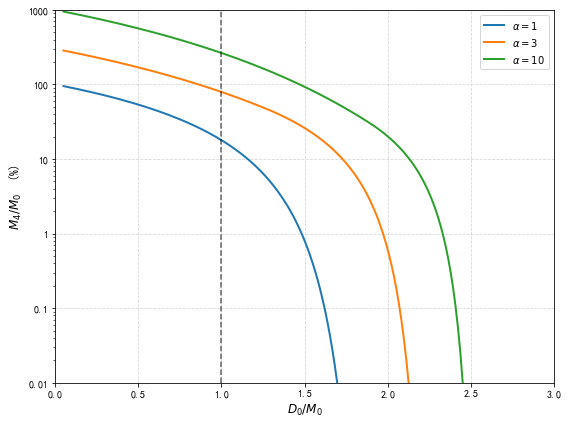

In [18]:
#  4层防御，α=1，3， 10
x_vals = np.linspace(0.05, 3, 200)
alphas = [1, 3, 10]
plt.figure(figsize=(8,6))

for alpha in alphas:
    M4_pct = []
    for ratio in x_vals:
        D0 = ratio * 1.0
        _, M_list = solve_n_layer_mirv(M0=1.0, D0=D0, alpha=alpha)
        M4_pct.append(M_list[-1] * 100)
    plt.plot(x_vals, M4_pct, label=f'$\\alpha={alpha}$', lw=2)

plt.xlabel('$D_0 / M_0$', fontsize=12)
plt.ylabel('$M_4 / M_0$  (%)', fontsize=12)
#plt.title('Figure 6.9  不同分裂弹头数下4层防御剩余比例', fontsize=14)
plt.yscale('log')
plt.yticks([0.01, 0.1, 1, 10, 100, 1000], ['0.01','0.1','1','10','100', '1000'])
plt.xlim(0,3)
plt.ylim(0.01,1000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, ls='--', color='k', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('Figure_6_9.png', dpi=300)
plt.show()

## 随机分配策略

In [11]:
def solve_two_layer(M0, N, p, tol=1e-8, max_iter=100):
    """求解2层防御系统，返回 N1, N2, M1, M2"""
    N2_low, N2_high = 0.0, N
    
    for _ in range(max_iter):
        N2 = (N2_low + N2_high) / 2
        N1 = N - N2
        M1 = M0 * np.exp(-p * N1 / M0) if M0 > 0 else 0
        N2_calc = (M0 - M1) / p if p > 0 else 0
        
        if abs(N2_calc - N2) < tol:
            break
        elif N2_calc < N2:
            N2_high = N2
        else:
            N2_low = N2
    
    # 计算 M2
    M2 = M1 * np.exp(-p * N2 / M1) if M1 > 0 else 0
    
    return N1, N2, M1, M2

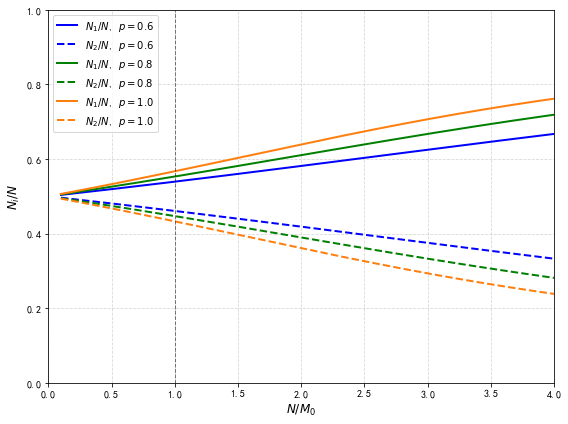

In [23]:
x_vals = np.linspace(0.1, 4, 150)  # N/M0 从 0.1 到 4
M0 = 1.0
p_vals = [0.6, 0.8, 1.0]
colors = ['b', 'g', '#ff7f0e']
line_styles = ['-', '--']

plt.figure(figsize=(8, 6))

for p, color in zip(p_vals, colors):
    N1_ratios = []
    N2_ratios = []
    
    for ratio in x_vals:
        N = ratio * M0
        N1, N2, _, _ = solve_two_layer(M0, N, p)
        N1_ratios.append(N1 / N if N > 0 else 0)
        N2_ratios.append(N2 / N if N > 0 else 0)
    
    plt.plot(x_vals, N1_ratios, label=f'$N_1/N$, $p={p}$', linewidth=2, color=color, linestyle='-')
    plt.plot(x_vals, N2_ratios, label=f'$N_2/N$, $p={p}$', linewidth=2, color=color, linestyle='--')

plt.xlabel('$N / M_0$', fontsize=12)
plt.ylabel('$N_i / N$', fontsize=12)
#plt.title('不同 p 值下防御资源分配比例随 $N/M_0$ 的变化', fontsize=14)
plt.xlim(0, 4)
plt.ylim(0, 1)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig('Figure_7_3.png', dpi=300)
plt.show()

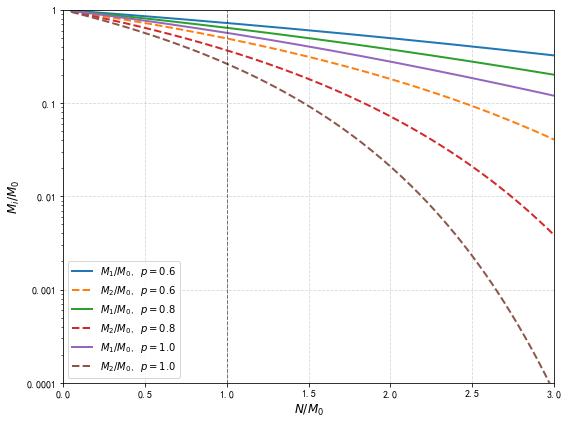

In [25]:
x_vals = np.linspace(0.05, 3, 150)  # N/M0 从 0.05 到 3
M0 = 1.0
p_vals = [0.6, 0.8, 1.0]

plt.figure(figsize=(8, 6))

for p in p_vals:
    M1_ratios = []
    M2_ratios = []
    
    for ratio in x_vals:
        N = ratio * M0
        _, _, M1, M2 = solve_two_layer(M0, N, p)
        M1_ratios.append(M1 / M0)
        M2_ratios.append(M2 / M0)
    
    plt.plot(x_vals, M1_ratios, label=f'$M_1/M_0$, $p={p}$', linewidth=2, linestyle='-')
    plt.plot(x_vals, M2_ratios, label=f'$M_2/M_0$, $p={p}$', linewidth=2, linestyle='--')

plt.xlabel('$N / M_0$', fontsize=12)
plt.ylabel('$M_i / M_0$', fontsize=12)
#plt.title('不同 p 值下剩余导弹比例随 $N/M_0$ 的变化', fontsize=14)
plt.xlim(0, 3)
plt.ylim(0.0001, 1)
plt.yscale('log')
plt.gca().set_yticks([0.0001, 0.001, 0.01, 0.1, 1])
plt.gca().set_yticklabels(['0.0001', '0.001', '0.01', '0.1', '1'])
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig('Figure_7_4.png', dpi=300)
plt.show()

## 均匀分配策略

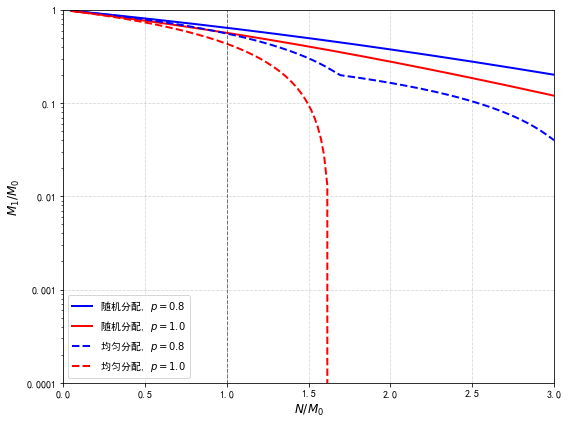

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 随机策略（最优分配）的求解函数 ==========
def solve_random_strategy(M0, N, p, tol=1e-8, max_iter=100):
    """
    随机策略（最优分配），求解 N1, N2, M1, M2
    使用之前的迭代法
    """
    N2_low, N2_high = 0.0, N
    
    for _ in range(max_iter):
        N2 = (N2_low + N2_high) / 2
        N1 = N - N2
        M1 = M0 * np.exp(-p * N1 / M0) if M0 > 0 else 0
        N2_calc = (M0 - M1) / p if p > 0 else 0
        
        if abs(N2_calc - N2) < tol:
            break
        elif N2_calc < N2:
            N2_high = N2
        else:
            N2_low = N2
    
    M2 = M1 * np.exp(-p * N2 / M1) if M1 > 0 else 0
    return N1, N2, M1, M2

# ========== 2. 均匀分配策略的 M1/M0 和 M2/M0 计算 ==========
def uniform_M1_ratio(N, M0, p, N1_over_N):
    """
    均匀分配策略下 M1/M0
    N1_over_N: 第一层防御资源占比（固定值，来自之前最优分配的结果）
    """
    N1 = N1_over_N * N
    N1_over_M0 = N1 / M0
    
    if N1_over_M0 >= 1:
        # 含取整的离散概率公式
        k = int(N1_over_M0)
        frac = N1_over_M0 - k
        # M1/M0 = (1-p)^k * (1 - p*frac)
        return (1 - p)**k * (1 - p * frac)
    else:
        # N/M0 < 1 时的线性公式
        return max(0, 1 - p * N1_over_M0)

def uniform_M2_ratio(N, M0, p, N1_over_N, M1_ratio):
    """
    均匀分配策略下 M2/M0
    M1_ratio: M1/M0 的值
    """
    N1 = N1_over_N * N
    N2 = N - N1
    N2_over_M1 = N2 / (M1_ratio * M0) if M1_ratio > 0 else 0
    
    if N2_over_M1 >= 1:
        # 含取整的离散概率公式
        k = int(N2_over_M1)
        frac = N2_over_M1 - k
        return M1_ratio * (1 - p)**k * (1 - p * frac)
    else:
        # N/M0 < 1 时的线性公式
        return max(0, 1 - p * N / M0)

# ========== 3. 图7.5：M1/M0 随 N/M0 变化 ==========
x_vals = np.linspace(0.05, 3, 150)  # N/M0
M0 = 1.0
p_vals = [0.8, 1.0]
colors = ['b', 'r']

plt.figure(figsize=(8, 6))

# 随机策略曲线（最优分配）
for p, color in zip(p_vals, colors):
    M1_ratios_random = []
    for ratio in x_vals:
        N = ratio * M0
        _, _, M1, _ = solve_random_strategy(M0, N, p)
        M1_ratios_random.append(M1 / M0)
    plt.plot(x_vals, M1_ratios_random, 
             label=f'随机分配, $p={p}$', 
             linewidth=2, color=color, linestyle='-')

# 均匀分配策略曲线
for p, color in zip(p_vals, colors):
    M1_ratios_uniform = []
    # 需要先获取 N1/N 的最优分配结果（来自随机策略）
    for ratio in x_vals:
        N = ratio * M0
        N1_opt, _, _, _ = solve_random_strategy(M0, N, p)
        N1_over_N_opt = N1_opt / N if N > 0 else 0
        M1_ratio = uniform_M1_ratio(N, M0, p, N1_over_N_opt)
        M1_ratios_uniform.append(M1_ratio)
    plt.plot(x_vals, M1_ratios_uniform, 
             label=f'均匀分配, $p={p}$', 
             linewidth=2, color=color, linestyle='--')

plt.xlabel('$N / M_0$', fontsize=12)
plt.ylabel('$M_1 / M_0$', fontsize=12)
#plt.title('图7.5 不同策略下 $M_1/M_0$ 随 $N/M_0$ 的变化', fontsize=14)
plt.xlim(0, 3)
plt.ylim(0.0001, 1)
plt.yscale('log')
plt.gca().set_yticks([0.0001, 0.001, 0.01, 0.1, 1])
plt.gca().set_yticklabels(['0.0001', '0.001', '0.01', '0.1', '1'])
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig('Figure_7_5.png', dpi=300)
plt.show()

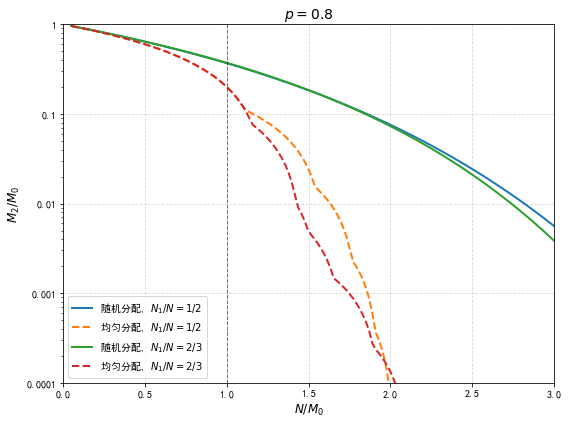

In [35]:
# ========== 4. 图7.6：M2/M0 随 N/M0 变化，p=0.8 ==========
x_vals = np.linspace(0.05, 3, 150)
M0 = 1.0
p = 0.8
N1_over_N_fixed = [1/2, 2/3]  # 固定分配比例
line_styles = ['-', '--']      # 实线=随机策略，虚线=均匀分配
markers = ['o', 's']

plt.figure(figsize=(8, 6))

for idx, N1_ratio in enumerate(N1_over_N_fixed):
    # 随机策略（使用迭代法，但 N1/N 固定）
    M2_ratios_random = []
    for ratio in x_vals:
        N = ratio * M0
        N1 = N1_ratio * N
        N2 = N - N1
        # 随机策略公式：M1 = M0 * exp(-p*N1/M0), M2 = M1 * exp(-p*N2/M1)
        M1 = M0 * np.exp(-p * N1 / M0) if M0 > 0 else 0
        M2 = M1 * np.exp(-p * N2 / M1) if M1 > 0 else 0
        M2_ratios_random.append(M2 / M0)
    
    # 均匀分配策略
    M2_ratios_uniform = []
    for ratio in x_vals:
        N = ratio * M0
        N1 = N1_ratio * N
        N2 = N - N1
        # 均匀分配下 M1/M0
        if N1 / M0 >= 1:
            k = int(N1 / M0)
            frac = N1 / M0 - k
            M1_ratio = (1 - p)**k * (1 - p * frac)
        else:
            M1_ratio = max(0, 1 - p * N1 / M0)
        
        # 均匀分配下 M2/M0
        N2_over_M1 = N2 / (M1_ratio * M0) if M1_ratio > 0 else 0
        if N2_over_M1 >= 1:
            k2 = int(N2_over_M1)
            frac2 = N2_over_M1 - k2
            M2_ratio = M1_ratio * (1 - p)**k2 * (1 - p * frac2)
        else:
            M2_ratio = max(0, 1 - p * N / M0)
        
        M2_ratios_uniform.append(M2_ratio)
    
    # 绘图
    plt.plot(x_vals, M2_ratios_random, 
         label=f'随机分配, $N_1/N=1/2$' if N1_ratio == 1/2 else f'随机分配, $N_1/N=2/3$', 
         linewidth=2, linestyle='-')
    plt.plot(x_vals, M2_ratios_uniform, 
         label=f'均匀分配, $N_1/N=1/2$' if N1_ratio == 1/2 else f'均匀分配, $N_1/N=2/3$', 
         linewidth=2, linestyle='--')

plt.xlabel('$N / M_0$', fontsize=12)
plt.ylabel('$M_2 / M_0$', fontsize=12)
plt.title('$p=0.8$', fontsize=14)
plt.xlim(0, 3)
plt.ylim(0.0001, 1)
plt.yscale('log')
plt.gca().set_yticks([0.0001, 0.001, 0.01, 0.1, 1])
plt.gca().set_yticklabels(['0.0001', '0.001', '0.01', '0.1', '1'])
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig('Figure_7_6.png', dpi=300)
plt.show()

## 零穿透概率

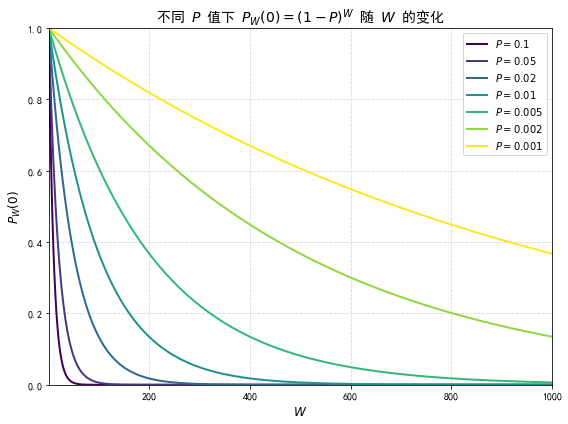

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 参数设置
W_vals = np.linspace(1, 1000, 500)  # W 从 1 到 1000
P_vals = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
colors = plt.cm.viridis(np.linspace(0, 1, len(P_vals)))  # 渐变色

plt.figure(figsize=(8, 6))

for P, color in zip(P_vals, colors):
    P_W0 = (1 - P) ** W_vals
    plt.plot(W_vals, P_W0, label=f'$P = {P}$', linewidth=2, color=color)

plt.xlabel('$W$', fontsize=12)
plt.ylabel('$P_W(0)$', fontsize=12)
plt.title('不同 $P$ 值下 $P_W(0) = (1-P)^W$ 随 $W$ 的变化', fontsize=14)
plt.xlim(1, 1000)
plt.ylim(0, 1)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('P_W_0_curve.png', dpi=300)
plt.show()

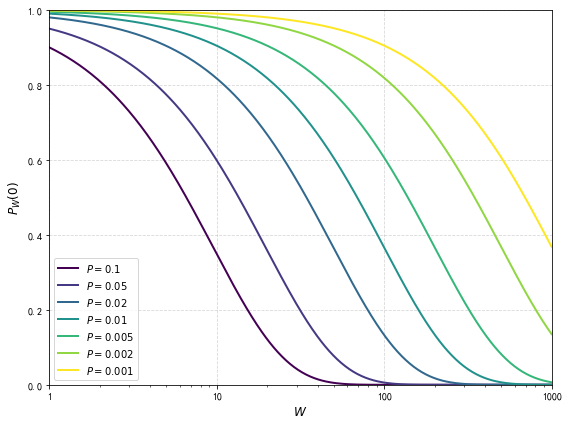

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 参数设置
W_vals = np.logspace(0, 3, 500)  # 从 10^0=1 到 10^3=1000，对数均匀分布
P_vals = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
colors = plt.cm.viridis(np.linspace(0, 1, len(P_vals)))

plt.figure(figsize=(8, 6))

for P, color in zip(P_vals, colors):
    P_W0 = (1 - P) ** W_vals
    plt.plot(W_vals, P_W0, label=f'$P = {P}$', linewidth=2, color=color)

plt.xlabel('$W$', fontsize=12)
plt.ylabel('$P_W(0)$', fontsize=12)
#plt.title('不同 $P$ 值下 $P_W(0) = (1-P)^W$ 随 $W$ 的变化', fontsize=14)
plt.xscale('log')  # 关键：对数坐标，使 1-10、10-100、100-1000 等长
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().set_xticks([1, 10, 100, 1000])
plt.gca().set_xticklabels(['1', '10', '100', '1000'])
plt.xlim(1, 1000)
plt.ylim(0, 1)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Figure_7_7.png', dpi=300)
plt.show()